# Análise Orbital de Asteroides (NEOs) — Relatório Final

**Disciplina:** Introdução à Ciência de Dados — Prof. Yuri Malheiros
**Instituição:** Universidade Federal da Paraíba (UFPB)

**Integrantes:**
- João Pedro da Silva Araújo
- Brenda Letícia do N. Dias
- Alonso da Costa Sousa Araújo
- Pedro Lucas Moreira Rolim

**Repositório:** https://github.com/jpedro-sci/analise-orbital


## 1. Introdução

Asteroides que cruzam a órbita da Terra (NEOs — *Near-Earth Objects*) são acompanhados de perto pela
NASA por representarem, em maior ou menor grau, um risco de colisão com o nosso planeta. Cada
aproximação registrada carrega informações sobre o tamanho do corpo, a velocidade com que ele passa
e a distância mínima até a Terra — e é justamente a combinação dessas variáveis que define o quão
preocupante (ou não) um determinado asteroide é.

### Motivação

Queremos colocar a mão na massa com dados reais e vivos. Por isso, em vez de recorrer a bases de dados prontas e mastigadas, fomos direto à fonte. Consumimos a API pública da NASA (NeoWs) para extrair, por conta própria, o histórico completo de aproximações da última década.

### O que vamos investigar neste notebook:

Nosso objetivo aqui é explorar esse universo de dados para extrair inteligência deles. Especificamente, nós vamos:

- **Mapear o Cenário:** Entender como o diâmetro, a velocidade e a distância de aproximação desses corpos se comportam e como interagem entre si.
- **Desmascarar os Perigosos:** Investigar se os asteroides que a NASA carimba como "ameaça" (potencialmente perigosos) realmente possuem assinaturas estatísticas diferentes dos inofensivos.
- **Testar Modelos Preditivos:** Aplicar regressão linear para tentar prever a distância mínima de aproximação de um asteroide baseando-se apenas no seu tamanho e na sua velocidade.
- **Prever e Concluir:** Usar algoritmos de clustering (agrupamento não supervisionado) para tentar segmentar esses asteroides em "perfis" de comportamento (como os "pequenos e lentos" ou os "gigantes e rápidos"), sem usar nenhum rótulo prévio de ameaça.

## 2. Dados usados

### 2.1 Descrição do dataset

Os dados foram coletados diretamente da API pública da NASA (**NeoWs — Near Earth Object Web Service**).
Como a API só permite extrair 7 dias de dados por requisição, construímos um script em Python
(`coleta.py`, disponível no repositório) que percorre o intervalo de 10 anos semana a semana, baixa o
JSON retornado, descarta as informações que não interessam para a análise e organiza o restante em um
`DataFrame` do pandas, exportado como `asteroides_10_anos.csv`.

Cada linha do arquivo representa **uma aproximação de um asteroide à Terra**, com as seguintes colunas:

| Coluna | Descrição |
|---|---|
| `id` | Código único de registro do asteroide no catálogo da NASA |
| `nome` | Nome oficial ou código de identificação do asteroide |
| `diametro_min_m` | Diâmetro mínimo estimado (metros) |
| `diametro_max_m` | Diâmetro máximo estimado (metros) |
| `velocidade_km_s` | Velocidade relativa no momento de maior aproximação (km/s) |
| `distancia_km` | Distância mínima até a Terra nessa aproximação (km) |
| `ameaca` | `True`/`False` — se a NASA classifica o asteroide como potencialmente perigoso |

### 2.2 Exploração inicial


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv("asteroides_10_anos.csv")
print("Dimensões do dataset:", df.shape)
df.head()

Dimensões do dataset: (13490, 7)


,id,nome,diametro_min_m,diametro_max_m,velocidade_km_s,distancia_km,ameaca
0,2468005,468005 (2012 XD112),153.657929,343.589575,5.237649,5.744741e+07,True
1,2470310,470310 (2007 LB15),318.093633,711.278987,21.455107,3.124649e+07,True
2,3595926,(2012 BV1),1.677085,3.750075,14.418240,3.042894e+07,False
3,3645042,(2013 ND15),40.230458,89.958039,17.183649,1.092496e+07,False
4,3733849,(2015 VL64),5.815070,13.002893,12.689488,5.512602e+07,False


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13490 entries, 0 to 13489
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               13490 non-null  int64  
 1   nome             13490 non-null  str    
 2   diametro_min_m   13490 non-null  float64
 3   diametro_max_m   13490 non-null  float64
 4   velocidade_km_s  13490 non-null  float64
 5   distancia_km     13490 non-null  float64
 6   ameaca           13490 non-null  bool   
dtypes: bool(1), float64(4), int64(1), str(1)
memory usage: 645.6 KB


In [4]:
df.describe()

,id,diametro_min_m,diametro_max_m,velocidade_km_s,distancia_km
count,1.349000e+04,13490.000000,13490.000000,13490.000000,1.349000e+04
mean,4.068594e+06,127.551085,285.212897,13.023502,2.835522e+07
std,5.029654e+06,280.105175,626.334212,7.033752,2.190433e+07
min,2.000433e+06,0.817627,1.828269,0.075402,7.030292e+03
25%,3.557534e+06,22.108281,49.435619,7.686084,8.921622e+06
50%,3.763420e+06,55.533491,124.176661,11.830297,2.366323e+07
75%,3.831195e+06,154.189869,344.779028,17.069904,4.563459e+07
max,5.460749e+07,22108.281036,49435.619262,65.830591,7.479169e+07


In [5]:
df["ameaca"].value_counts(normalize=True).mul(100).round(2)

ameaca
False    89.36
True     10.64
Name: proportion, dtype: float64

## 3. Pré-processamento

Antes de responder às perguntas, verificamos a qualidade dos dados e fizemos alguns ajustes:

- **Valores ausentes e duplicados:** checamos se existem valores nulos ou linhas duplicadas — o
  script de coleta já filtra os dados no momento da extração, então não esperávamos encontrar muita
  sujeira, mas é importante confirmar isso antes de qualquer análise.
- **Nova coluna `diametro_medio_m`:** o dataset traz o diâmetro como uma faixa (`diametro_min_m` e
  `diametro_max_m`, que na verdade são estimativas, não medições exatas). Para facilitar a análise
  (histogramas, correlações, regressão e clustering), criamos a coluna `diametro_medio_m`, que é a
  média simples entre os dois valores e representa um único número por asteroide.
- **Conversão da coluna `ameaca`:** convertida para inteiro (0/1) para facilitar comparações
  numéricas e correlações, mantendo uma cópia como categórica (`Sim`/`Não`) para os gráficos.
- **Checagem de outliers:** olhamos a distribuição de cada variável numérica para identificar valores
  extremos que pudessem distorcer médias e modelos (comum em dados astronômicos, onde alguns poucos
  objetos são muito maiores ou passam muito mais perto que a maioria).


In [6]:
print("Valores nulos por coluna:")
print(df.isna().sum())
print("\nLinhas duplicadas:", df.duplicated().sum())
print("IDs duplicados:", df.duplicated(subset=["id"]).sum())

Valores nulos por coluna:
id                 0
nome               0
diametro_min_m     0
diametro_max_m     0
velocidade_km_s    0
distancia_km       0
ameaca             0
dtype: int64

Linhas duplicadas: 0
IDs duplicados: 0


In [7]:
df["diametro_medio_m"] = (df["diametro_min_m"] + df["diametro_max_m"]) / 2
df["ameaca_num"] = df["ameaca"].astype(int)
df["ameaca_label"] = df["ameaca"].map({True: "Sim", False: "Não"})

df[["diametro_min_m", "diametro_max_m", "diametro_medio_m", "ameaca", "ameaca_label"]].head()

,diametro_min_m,diametro_max_m,diametro_medio_m,ameaca,ameaca_label
0,153.657929,343.589575,248.623752,True,Sim
1,318.093633,711.278987,514.686310,True,Sim
2,1.677085,3.750075,2.713580,False,Não
3,40.230458,89.958039,65.094248,False,Não
4,5.815070,13.002893,9.408982,False,Não


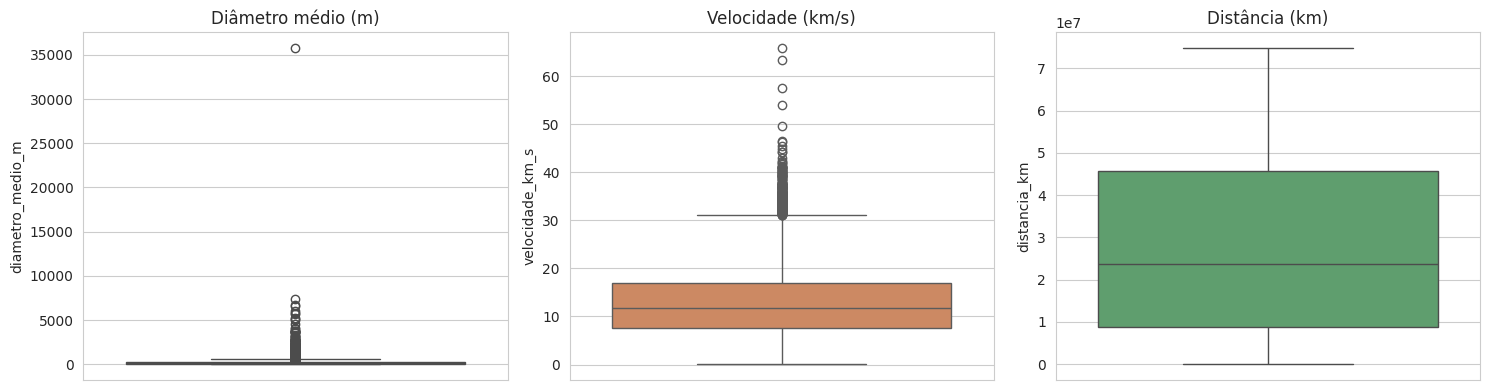

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(y=df["diametro_medio_m"], ax=axes[0], color="#4C72B0")
axes[0].set_title("Diâmetro médio (m)")
sns.boxplot(y=df["velocidade_km_s"], ax=axes[1], color="#DD8452")
axes[1].set_title("Velocidade (km/s)")
sns.boxplot(y=df["distancia_km"], ax=axes[2], color="#55A868")
axes[2].set_title("Distância (km)")
plt.tight_layout()
plt.show()

Os boxplots mostram que as três variáveis têm uma cauda longa à direita — ou seja, a maioria dos
asteroides é pequena, lenta e passa relativamente perto, mas existe uma minoria de objetos bem maiores,
mais rápidos e/ou mais distantes puxando a média para cima. Isso é esperado nesse tipo de fenômeno
natural (poucos eventos extremos, muitos eventos "comuns") e optamos por não remover esses pontos,
pois eles são justamente os candidatos mais relevantes quando o assunto é risco de impacto — removê-los
enviesaria a análise exatamente na direção oposta ao objetivo do projeto.


## 4. Perguntas e Análises

### Pergunta 1 — Como estão distribuídos o tamanho e a velocidade dos asteroides da nossa base?

Antes de comparar grupos ou construir modelos, é importante entender os dados que temos: a
maioria dos asteroides é pequena ou grande? Rápida ou lenta?


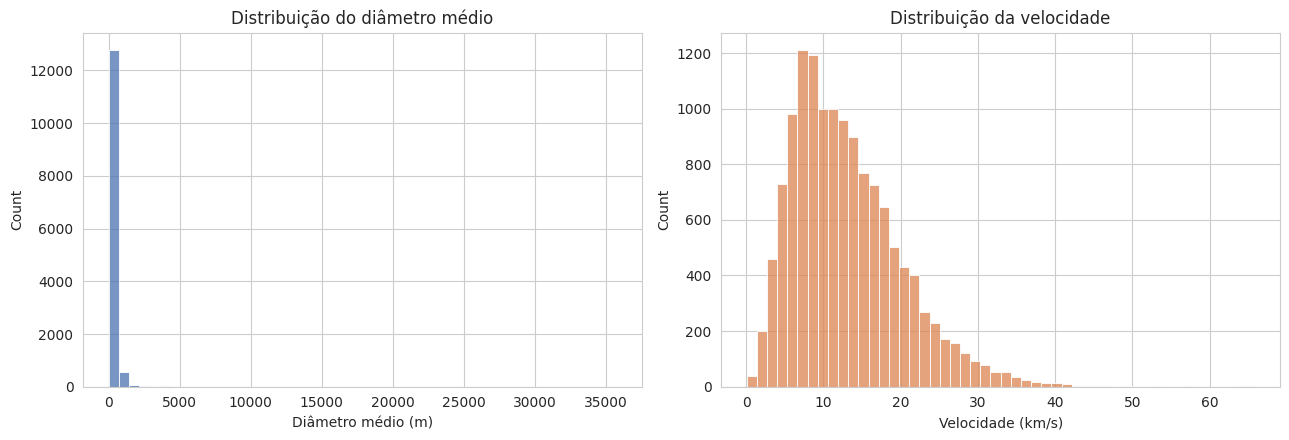

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["diametro_medio_m"], bins=50, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribuição do diâmetro médio")
axes[0].set_xlabel("Diâmetro médio (m)")

sns.histplot(df["velocidade_km_s"], bins=50, ax=axes[1], color="#DD8452")
axes[1].set_title("Distribuição da velocidade")
axes[1].set_xlabel("Velocidade (km/s)")

plt.tight_layout()
plt.show()

**Conclusão:** As duas distribuições são assimétricas à direita (right-skewed). A maior parte dos
asteroides observados tem diâmetro médio abaixo de 150 m e velocidade entre 5 e 20 km/s, mas há uma
cauda de objetos maiores e mais rápidos que, embora minoritários, não podem ser ignorados.


### Pergunta 2 — Existe relação entre o tamanho do asteroide e sua velocidade?

Faz sentido perguntar se objetos maiores tendem a se mover mais rápido (ou mais devagar) em relação
à Terra. Para isso, olhamos a correlação entre diametro_medio_m e velocidade_km_s.


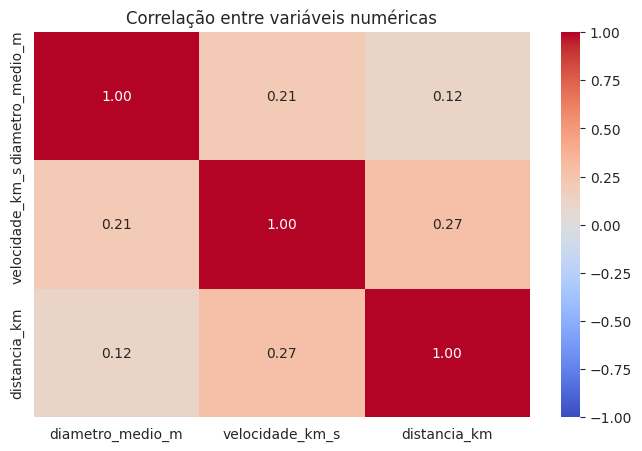

In [10]:
corr = df[["diametro_medio_m", "velocidade_km_s", "distancia_km"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlação entre variáveis numéricas")
plt.show()

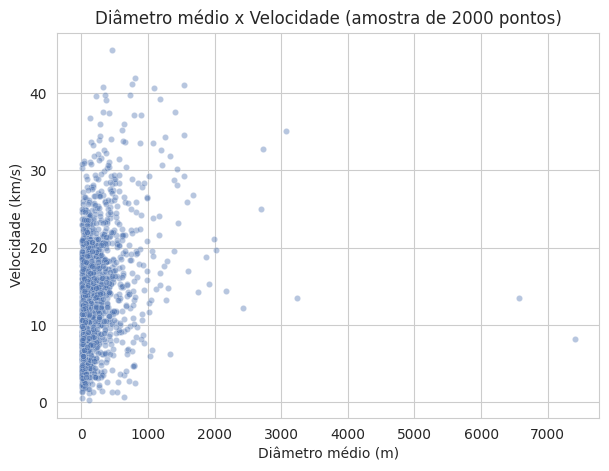

Correlação diâmetro x velocidade: 0.21


In [11]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df.sample(2000, random_state=42), x="diametro_medio_m", y="velocidade_km_s",
                 alpha=0.4, s=20, color="#4C72B0")
plt.title("Diâmetro médio x Velocidade (amostra de 2000 pontos)")
plt.xlabel("Diâmetro médio (m)")
plt.ylabel("Velocidade (km/s)")
plt.show()

print("Correlação diâmetro x velocidade:", round(df["diametro_medio_m"].corr(df["velocidade_km_s"]), 3))

**Conclusão:** A correlação é fraca e positiva. Existe uma leve tendência de asteroides maiores
aparecerem com velocidades um pouco mais altas, mas a relação está longe de ser forte — o tamanho
sozinho explica muito pouco da velocidade observada, então outros fatores (como a órbita específica de
cada objeto) pesam mais nessa equação.


### Pergunta 3 — Os asteroides marcados como "ameaça" realmente diferem dos demais em tamanho, velocidade e distância?

A NASA classifica um NEO como potencialmente perigoso combinando critérios de tamanho e proximidade
orbital. Queremos confirmar, olhando para os dados, se essa classificação se reflete de forma visível
nas três variáveis que temos disponíveis.


/tmp/ipykernel_19513/2069902637.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="ameaca_label", y="diametro_medio_m", ax=axes[0], palette="Set2")
/tmp/ipykernel_19513/2069902637.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="ameaca_label", y="velocidade_km_s", ax=axes[1], palette="Set2")
/tmp/ipykernel_19513/2069902637.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="ameaca_label", y="distancia_km", ax=axes[2], palette="Set2")


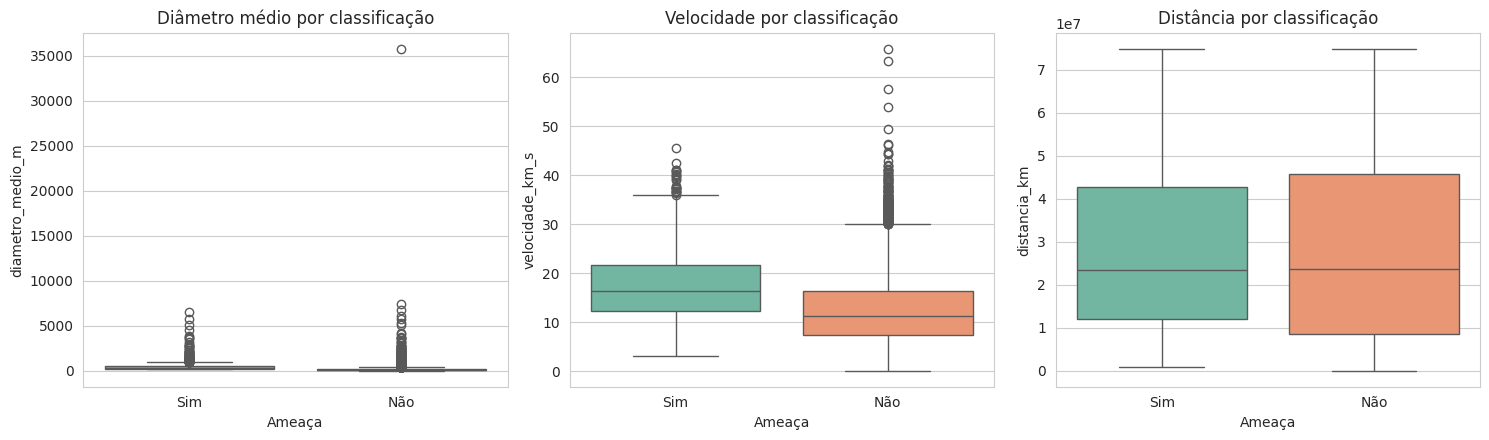

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.boxplot(data=df, x="ameaca_label", y="diametro_medio_m", ax=axes[0], palette="Set2")
axes[0].set_title("Diâmetro médio por classificação")
axes[0].set_xlabel("Ameaça")

sns.boxplot(data=df, x="ameaca_label", y="velocidade_km_s", ax=axes[1], palette="Set2")
axes[1].set_title("Velocidade por classificação")
axes[1].set_xlabel("Ameaça")

sns.boxplot(data=df, x="ameaca_label", y="distancia_km", ax=axes[2], palette="Set2")
axes[2].set_title("Distância por classificação")
axes[2].set_xlabel("Ameaça")

plt.tight_layout()
plt.show()

In [13]:
df.groupby("ameaca_label")[["diametro_medio_m", "velocidade_km_s", "distancia_km"]].median()

,diametro_medio_m,velocidade_km_s,distancia_km
ameaca_label,,,
Não,73.036948,11.247655,2.372099e+07
Sim,330.782570,16.276200,2.346077e+07


**Conclusão:** Os asteroides marcados como ameaça têm, em geral, diâmetro mediano bem maior
que os demais — essa é a diferença mais clara dos três gráficos. A velocidade também tende a ser um
pouco mais alta no grupo de ameaça, enquanto a distância mínima não mostra uma diferença tão marcante.
Isso confirma que o critério de tamanho pesa bastante na classificação de risco da NASA.


### Pergunta 4 — É possível prever a distância mínima de aproximação a partir do diâmetro e da velocidade? 

Se diâmetro e velocidade tivessem uma relação forte com a distância de aproximação, poderíamos usar um
modelo simples para estimar a que distância um novo asteroide passaria da Terra. Testamos essa ideia
com uma regressão linear múltipla.


In [14]:
X = df[["diametro_medio_m", "velocidade_km_s"]]
y = df["distancia_km"]

modelo = LinearRegression()
modelo.fit(X, y)

y_pred = modelo.predict(X)

print("Coeficientes:", dict(zip(X.columns, modelo.coef_.round(2))))
print("Intercepto:", round(modelo.intercept_, 2))
print("R²:", round(r2_score(y, y_pred), 4))
print("Erro absoluto médio (km):", round(mean_absolute_error(y, y_pred), 2))

Coeficientes: {'diametro_medio_m': np.float64(3001.51), 'velocidade_km_s': np.float64(811230.62)}
Intercepto: 17170694.38
R²: 0.0785
Erro absoluto médio (km): 17900224.14


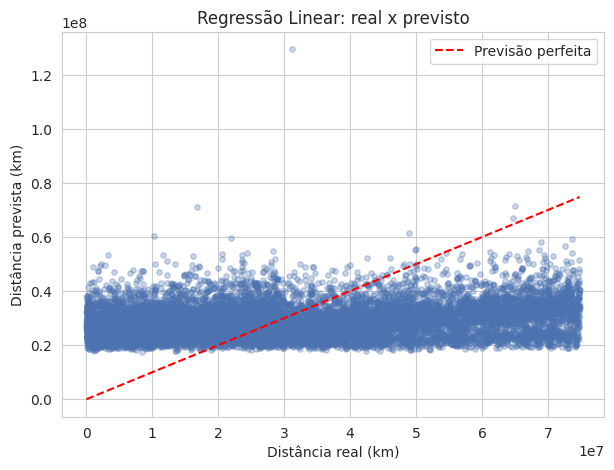

In [15]:
plt.figure(figsize=(7, 5))
plt.scatter(y, y_pred, alpha=0.3, s=15, color="#4C72B0")
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red", linestyle="--", label="Previsão perfeita")
plt.xlabel("Distância real (km)")
plt.ylabel("Distância prevista (km)")
plt.title("Regressão Linear: real x previsto")
plt.legend()
plt.show()

**Conclusão:** O R² do modelo é bem baixo, o que mostra que diâmetro e velocidade não são bons
preditores da distância mínima de aproximação — no gráfico de real x previsto, os pontos estão
espalhados e longe da linha de previsão perfeita. Isso faz sentido fisicamente: a distância de
aproximação depende principalmente da geometria da órbita do asteroide, uma informação que não está
presente no nosso dataset. O resultado é útil como conclusão negativa: reforça que, para prever
distância, precisaríamos incluir dados orbitais.


### Pergunta 5 — É possível agrupar os asteroides em perfis com características parecidas, sem usar o rótulo de ameaça? 

Ao invés de usar a classificação já dada pela NASA, queremos ver se um algoritmo de agrupamento não
supervisionado (KMeans) consegue, sozinho, encontrar grupos de asteroides parecidos usando apenas
diâmetro, velocidade e distância — e depois checar se esses grupos batem, de alguma forma, com a
classificação real de ameaça.


In [16]:
features = df[["diametro_medio_m", "velocidade_km_s", "distancia_km"]]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(features_scaled)

df.groupby("cluster")[["diametro_medio_m", "velocidade_km_s", "distancia_km"]].mean().round(2)

,diametro_medio_m,velocidade_km_s,distancia_km
cluster,,,
0,124.61,9.92,15775300.24
1,336.37,18.23,49436803.05
2,35771.95,6.04,31205919.27


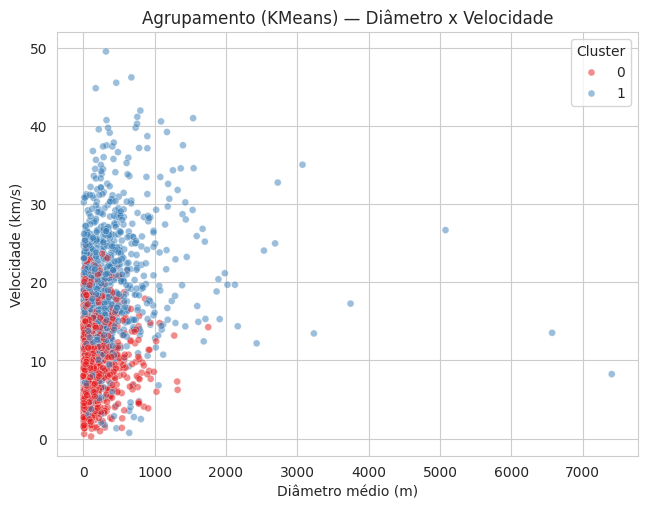

In [17]:
plt.figure(figsize=(7.5, 5.5))
sns.scatterplot(data=df.sample(3000, random_state=42), x="diametro_medio_m", y="velocidade_km_s",
                 hue="cluster", palette="Set1", alpha=0.5, s=25)
plt.title("Agrupamento (KMeans) — Diâmetro x Velocidade")
plt.xlabel("Diâmetro médio (m)")
plt.ylabel("Velocidade (km/s)")
plt.legend(title="Cluster")
plt.show()

In [18]:
pd.crosstab(df["cluster"], df["ameaca_label"], normalize="index").mul(100).round(1)

ameaca_label,Não,Sim
cluster,,
0,91.8,8.2
1,85.3,14.7
2,100.0,0.0


**Conclusão:** O KMeans separou os asteroides em grupos que se diferenciam principalmente pelo
diâmetro (um cluster concentra os objetos maiores, outro os menores e mais numerosos). Ao cruzar os
clusters com a classificação real de ameaça, o cluster com os maiores diâmetros médios também é o que
concentra a maior proporção de asteroides marcados como ameaça — ou seja, mesmo sem receber o rótulo
como entrada, o algoritmo encontrou uma estrutura nos dados que se aproxima do critério real usado pela
NASA, reforçando a conclusão da Pergunta 3 de que o tamanho é o fator mais determinante.


## 5. Conclusão

Com a análise de 10 anos de aproximações de NEOs coletados diretamente da API da NASA, encontramos que:

- A maioria dos asteroides observados é pequena e relativamente lenta, com uma minoria de objetos bem
  maiores e mais rápidos puxando a distribuição para a direita;
- O diâmetro e a velocidade têm correlação fraca entre si — tamanho não explica bem a velocidade;
- O diâmetro é o fator que mais separa os asteroides classificados como "ameaça" dos demais, mais
  do que a velocidade ou a distância mínima registrada;
- Um modelo de regressão linear usando apenas diâmetro e velocidade não conseguiu prever bem a
  distância mínima de aproximação (R² baixo), sugerindo que dados orbitais adicionais seriam
  necessários para essa tarefa;
- Um modelo de agrupamento (KMeans), mesmo sem usar o rótulo de ameaça, encontrou grupos que se
  aproximam da classificação real da NASA, evidenciando que o tamanho é de fato o critério mais
  informativo entre os que temos disponíveis.

**Limitações:**
- O dataset não inclui parâmetros orbitais (excentricidade, inclinação etc.), que provavelmente são
  mais determinantes para prever distância e risco do que diâmetro e velocidade isolados;
- A classe "ameaça" é bastante desbalanceada (~10,6% dos registros), o que pode limitar a robustez de
  modelos supervisionados futuros;
- Diâmetro é uma estimativa (faixa min/max) e não uma medição direta, o que introduz incerteza.

**Melhorias:**
- Incorporar dados orbitais da própria API da NASA (ou de outras fontes, como o JPL Small-Body Database)
  para melhorar o poder preditivo dos modelos;
- Testar modelos de classificação supervisionada (ex: árvore de decisão, regressão logística) para
  prever diretamente a variável ameaca, tratando o desbalanceamento de classes;
- Testar diferentes números de clusters (método do cotovelo / silhueta) para validar se 3 é de fato o
  número ideal de grupos.
